# Assignment 4 — Pre-trained Embeddings in a Downstream Task

**Vishal Sigdel** · MTech NLP · Chapter 3

**Objective.** Load pre-trained **GloVe** vectors and use them as input to a **sentiment
classifier**, then measure what the pre-training is actually worth by comparing against models that
do not get it.

| Task | Section |
|---|---|
| Load GloVe (and FastText) embeddings | §1 |
| Use embeddings as input for sentiment classification | §3–§5 |
| Compare performance with and without embeddings | §6 |

**Dataset.** NLTK **`movie_reviews`** — the Pang & Lee polarity dataset: 2 000 full IMDb reviews,
1 000 positive and 1 000 negative, ~1.33 M alphabetic tokens (median review ~630 tokens). Small on purpose: with 2 000 labelled examples the
model cannot learn good word representations from the task alone, which is exactly the regime where
pre-trained embeddings should help. On a million labelled reviews the comparison would be far less
interesting.

**The comparison.** Five models, all evaluated on the same held-out split:

| # | Model | Word vectors | Trained on the task? |
|---|---|---|---|
| 1 | Bag-of-words + logistic regression | none (sparse counts) | — |
| 2 | Mean-embedding + logistic regression | GloVe, frozen | classifier only |
| 3 | Neural bag-of-words | random init, learned | yes |
| 4 | Neural bag-of-words | GloVe init, frozen | classifier only |
| 5 | Neural bag-of-words | GloVe init, fine-tuned | yes |

Models 3 vs 4 vs 5 isolate the two questions that matter: *does pre-training help?* and *should the
vectors keep moving during training?* They share an architecture, a split, and a schedule, so any
difference between them comes from the embedding table alone. Model 1 is the classical baseline that
any embedding-based model has to beat to justify itself. §7 then swaps in our own Assignment-3 SGNS
vectors, putting a number on "1 M tokens of Brown vs 6 B tokens of Wikipedia".

One result worth flagging up front, because it is easy to misread: **the frozen arm scores lowest of
the three.** §5 and §6 show why that is a statement about trainable capacity rather than about GloVe,
and why the fine-tuned arm — same vectors, same parameter count as random-init — is the one that
answers the assignment's question.

In [1]:
import collections
import json
import pathlib
import random
import time
import zipfile
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA = pathlib.Path("data"); DATA.mkdir(exist_ok=True)
ARTIFACTS = pathlib.Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("torch", torch.__version__, "| device:", DEVICE)

torch 2.13.0+cu130 | device: cuda


<a id="1"></a>
## §1 — Load pre-trained embeddings

**GloVe** (Pennington et al., 2014) factorises a global word-word co-occurrence matrix rather than
streaming local windows as word2vec does. The objective is weighted least squares on log-counts:

$$J = \sum_{i,j} f(X_{ij}) \left( w_i^\top \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$

with $f$ down-weighting very frequent pairs. Different route, similar destination — the vectors it
produces are used interchangeably with word2vec's in practice.

We use **`glove.6B.100d`**: 400 000 words, 100 dimensions, trained on 6 billion tokens of Wikipedia
2014 + Gigaword 5. The download is an 822 MB zip containing four dimensionalities (50d/100d/200d/300d);
only the 100d file is extracted (~347 MB). The zip is kept so a rerun does not re-download it —
delete `data/glove.6B.zip` afterwards if the disk space matters.

The loader below is deliberately vocabulary-restricted: parsing all 400 000 rows costs time and
~1.3 GB of RAM, while our task vocabulary is ~21 000 words. Filtering while reading keeps it to a
couple of seconds and a small fraction of the memory.

In [2]:
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP = DATA / "glove.6B.zip"
GLOVE_TXT = DATA / "glove.6B.100d.txt"
GLOVE_DIM = 100

def fetch_glove():
    "Download and extract glove.6B.100d.txt, skipping work already done."
    if GLOVE_TXT.exists():
        print(f"{GLOVE_TXT} already present ({GLOVE_TXT.stat().st_size / 1e6:.0f} MB)")
        return
    if not GLOVE_ZIP.exists():
        print(f"downloading {GLOVE_URL} (822 MB) ...")
        urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    print("extracting the 100d file ...")
    with zipfile.ZipFile(GLOVE_ZIP) as zf:
        with zf.open("glove.6B.100d.txt") as src, GLOVE_TXT.open("wb") as dst:
            dst.write(src.read())
    print(f"ready: {GLOVE_TXT.stat().st_size / 1e6:.0f} MB")

fetch_glove()

data/glove.6B.100d.txt already present (347 MB)


In [3]:
def load_vectors(path, keep=None, expected_dim=None):
    """Read a word2vec/GloVe text file into (word -> np.ndarray).

    `keep`: if given, only these words are parsed — the rest are skipped without
    allocating, which is the difference between 30 s and 1 s here.
    """
    vecs, dim = {}, expected_dim
    with open(path, "r", encoding="utf-8") as fh:
        first = fh.readline().split()
        # word2vec text format starts with a "<n_words> <dim>" header; GloVe does not.
        if len(first) == 2 and all(p.isdigit() for p in first):
            dim = int(first[1])
        else:
            fh.seek(0)
        for line in fh:
            parts = line.rstrip().split(" ")
            w = parts[0]
            if keep is not None and w not in keep:
                continue
            v = np.asarray(parts[1:], dtype=np.float32)
            if dim is None:
                dim = len(v)
            if len(v) == dim:
                vecs[w] = v
    return vecs, dim

t0 = time.perf_counter()
_probe, glove_dim = load_vectors(GLOVE_TXT, keep={"the", "king", "queen", "terrible", "superb"})
print(f"header probe in {time.perf_counter() - t0:.1f}s | dim = {glove_dim}")
for w, v in _probe.items():
    print(f"  {w:>9} {np.array2string(v[:5], precision=3, floatmode='fixed')} ... (norm {np.linalg.norm(v):.2f})")

header probe in 2.7s | dim = 100
        the [-0.038 -0.245  0.728 -0.400  0.083] ... (norm 5.82)
       king [-0.323 -0.876  0.220  0.253  0.230] ... (norm 6.12)
      queen [-0.500 -0.708  0.554  0.673  0.225] ... (norm 6.01)
   terrible [ 0.233  0.011  0.427 -0.326 -1.081] ... (norm 5.35)
     superb [ 0.029 -0.155 -0.152 -0.202  0.215] ... (norm 4.72)


### Do the pre-trained vectors know about sentiment?

Before wiring them into a classifier, a sanity check worth its two lines: sentiment-bearing words
should cluster by polarity in GloVe space. If they do not, no downstream gain is plausible.

In [4]:
POS_WORDS = ["excellent", "superb", "brilliant", "wonderful", "delightful"]
NEG_WORDS = ["terrible", "awful", "dreadful", "horrible", "lousy"]

probe_vecs, _ = load_vectors(GLOVE_TXT, keep=set(POS_WORDS + NEG_WORDS))
def unit(v): return v / max(np.linalg.norm(v), 1e-12)

Vp = np.stack([unit(probe_vecs[w]) for w in POS_WORDS if w in probe_vecs])
Vn = np.stack([unit(probe_vecs[w]) for w in NEG_WORDS if w in probe_vecs])

within_pos = (Vp @ Vp.T)[~np.eye(len(Vp), dtype=bool)].mean()
within_neg = (Vn @ Vn.T)[~np.eye(len(Vn), dtype=bool)].mean()
across    = (Vp @ Vn.T).mean()

print(f"mean cosine within positive words : {within_pos:.3f}")
print(f"mean cosine within negative words : {within_neg:.3f}")
print(f"mean cosine across polarities     : {across:.3f}")
print(f"separation                        : {(within_pos + within_neg) / 2 - across:+.3f}")
print("\nPositive: polarity is partially linearly recoverable, so a linear classifier on top has")
print("something to work with. Note the across-polarity similarity is still high -- antonyms share")
print("contexts, the same weakness seen in Assignment 3.")

mean cosine within positive words : 0.663
mean cosine within negative words : 0.761
mean cosine across polarities     : 0.444
separation                        : +0.269

Positive: polarity is partially linearly recoverable, so a linear classifier on top has
something to work with. Note the across-polarity similarity is still high -- antonyms share
contexts, the same weakness seen in Assignment 3.


## §2 — The sentiment dataset

`movie_reviews` is pre-tokenised. Two decisions:

* **Lowercase, keep punctuation-free alphabetic tokens.** GloVe 6B is itself lowercased and
  tokenised this way, so matching its convention maximises vocabulary hit rate — a mismatch here
  silently converts pre-trained words into out-of-vocabulary ones.
* **Stratified split, fixed seed:** 1 400 train / 300 validation / 300 test, balanced by class. With
  only 2 000 examples, a single unlucky split moves accuracy by several points, so the validation set
  exists to keep the test set untouched until §6.

In [5]:
nltk.download("movie_reviews", quiet=True)
from nltk.corpus import movie_reviews

def load_reviews():
    docs = []
    for label in ("neg", "pos"):
        for fid in movie_reviews.fileids(label):
            toks = [t.lower() for t in movie_reviews.words(fid) if t.isalpha()]
            docs.append((toks, 1 if label == "pos" else 0))
    return docs

t0 = time.perf_counter()
docs = load_reviews()
rng = random.Random(SEED)
rng.shuffle(docs)

# Stratified split so both classes stay balanced in all three parts.
by_class = {0: [d for d in docs if d[1] == 0], 1: [d for d in docs if d[1] == 1]}
train, val, test = [], [], []
for lab, items in by_class.items():
    train += items[:700]; val += items[700:850]; test += items[850:]
for part in (train, val, test):
    rng.shuffle(part)

lengths = np.array([len(t) for t, _ in docs])
print(f"loaded {len(docs)} reviews in {time.perf_counter() - t0:.1f}s")
print(f"split          : {len(train)} train / {len(val)} val / {len(test)} test")
print(f"class balance  : train {np.mean([y for _, y in train]):.2f}, "
      f"val {np.mean([y for _, y in val]):.2f}, test {np.mean([y for _, y in test]):.2f}")
print(f"review length  : median {int(np.median(lengths))}, mean {lengths.mean():.0f}, "
      f"p95 {int(np.percentile(lengths, 95))} tokens")
print(f"total tokens   : {lengths.sum():,}")
print("\nfirst 30 tokens of one review (label={}):".format(train[0][1]))
print(" ", " ".join(train[0][0][:30]), "...")

loaded 2000 reviews in 1.4s
split          : 1400 train / 300 val / 300 test
class balance  : train 0.50, val 0.50, test 0.50
review length  : median 626, mean 665, p95 1214 tokens
total tokens   : 1,329,753

first 30 tokens of one review (label=0):
  okay okay maybe i wasn t in the mood to watch a mindless action movie i am the same person that liked lethal weapon iii even while admitting that it ...


In [6]:
# Vocabulary over the TRAINING split only. Building it on all splits would leak test information
# into the model's input space -- a small leak here, but the habit matters.
MIN_COUNT = 2
train_counts = collections.Counter(w for toks, _ in train for w in toks)
itos = ["<pad>", "<unk>"] + [w for w, c in train_counts.most_common() if c >= MIN_COUNT]
stoi = {w: i for i, w in enumerate(itos)}
PAD, UNK = 0, 1

print(f"train types            : {len(train_counts):,}")
print(f"vocabulary (min_count={MIN_COUNT}) : {len(itos):,}")

oov_val = np.mean([w not in stoi for toks, _ in val for w in toks])
print(f"OOV token rate on val  : {oov_val:.1%}")

train types            : 33,705
vocabulary (min_count=2) : 21,535
OOV token rate on val  : 2.8%


### Coverage: how many of our words does GloVe actually have?

This number sets the ceiling on any gain. A word absent from GloVe gets a random vector regardless of
how good the pre-training was.

In [7]:
glove, glove_dim = load_vectors(GLOVE_TXT, keep=set(itos))

covered = [w for w in itos[2:] if w in glove]
tok_total = sum(train_counts[w] for w in itos[2:])
tok_cov   = sum(train_counts[w] for w in covered)

print(f"GloVe vectors loaded    : {len(glove):,} (of {len(itos):,} vocabulary entries)")
print(f"type coverage           : {len(covered) / (len(itos) - 2):.1%}")
print(f"token coverage          : {tok_cov / tok_total:.1%}")
print("\nA sample of what GloVe is missing:")
missing = [w for w in itos[2:] if w not in glove]
print(" ", missing[:20])
print(f"\n{len(missing)} missing types, mostly rare names and misspellings -- they carry")
print("little weight, which is why token coverage is far higher than type coverage.")

GloVe vectors loaded    : 21,183 (of 21,535 vocabulary entries)
type coverage           : 98.4%
token coverage          : 99.9%

A sample of what GloVe is missing:
  ['hadn', 'psychlos', 'joblo', 'artagnan', 'psychlo', 'hrundi', 'groeteschele', 'skarsg', 'stargher', 'verhoven', 'cyborsuit', 'laserman', 'fflewdurr', 'tswsm', 'nookey', 'rumpo', 'shelmikedmu', 'cheezy', 'arraki', 'motss']

350 missing types, mostly rare names and misspellings -- they carry
little weight, which is why token coverage is far higher than type coverage.


In [8]:
def build_embedding_matrix(vecs, itos, dim, seed=SEED):
    """Assemble the (V, dim) initialisation table.

    Rows: <pad> stays exactly zero; words found in `vecs` get their pre-trained vector;
    the rest get small random noise scaled to the pre-trained vectors' own standard deviation,
    so no row starts out anomalously large.
    """
    rng = np.random.default_rng(seed)
    scale = float(np.std(np.stack(list(vecs.values())))) if vecs else 0.1
    M = rng.normal(0.0, scale, size=(len(itos), dim)).astype(np.float32)
    M[PAD] = 0.0
    hits = 0
    for i, w in enumerate(itos):
        if w in vecs:
            M[i] = vecs[w]; hits += 1
    return M, hits

EMB_GLOVE, hits = build_embedding_matrix(glove, itos, glove_dim)
print(f"embedding matrix {EMB_GLOVE.shape} | {hits:,} rows pre-trained "
      f"({hits / len(itos):.1%}), remainder random")

embedding matrix (21535, 100) | 21,183 rows pre-trained (98.4%), remainder random


<a id="3"></a>
## §3 — Baseline 1: bag-of-words, no embeddings at all

TF-IDF over unigrams and bigrams with logistic regression. This is the model embeddings are supposed
to improve on, and on 2 000 balanced documents it is a genuinely strong opponent: sentiment in movie
reviews is carried largely by individual lexical cues (`boring`, `worst`, `perfect`), which sparse
features capture exactly and losslessly.

In [9]:
def joined(part): return [" ".join(toks) for toks, _ in part], np.array([y for _, y in part])

Xtr_txt, ytr = joined(train)
Xva_txt, yva = joined(val)
Xte_txt, yte = joined(test)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr = tfidf.fit_transform(Xtr_txt)
Xva, Xte = tfidf.transform(Xva_txt), tfidf.transform(Xte_txt)

bow_clf = LogisticRegression(max_iter=2000, C=4.0, random_state=SEED).fit(Xtr, ytr)
bow_val = accuracy_score(yva, bow_clf.predict(Xva))
bow_test = accuracy_score(yte, bow_clf.predict(Xte))

print(f"features         : {Xtr.shape[1]:,} (unigrams + bigrams)")
print(f"val accuracy     : {bow_val:.3f}")
print(f"test accuracy    : {bow_test:.3f}")
print(f"test macro F1    : {f1_score(yte, bow_clf.predict(Xte), average='macro'):.3f}")

# What the sparse model keyed on -- a useful contrast with the embedding models below.
names = np.array(tfidf.get_feature_names_out())
coef = bow_clf.coef_[0]
print("\nmost positive features:", ", ".join(names[np.argsort(-coef)[:10]]))
print("most negative features:", ", ".join(names[np.argsort(coef)[:10]]))

features         : 102,803 (unigrams + bigrams)
val accuracy     : 0.880
test accuracy    : 0.850
test macro F1    : 0.850

most positive features: great, well, he is, life, also, both, very, world, the best, perfect
most negative features: bad, worst, boring, supposed, the worst, stupid, plot, supposed to, only, nothing


## §4 — Baseline 2: frozen GloVe means, no neural network

The cheapest possible use of pre-trained embeddings: average each review's word vectors into one
100-dimensional point and fit logistic regression on that. No task-specific representation learning
at all — the embeddings do all the representational work.

The averaging discards word order and, worse, treats negation as invisible: `not good` averages to
something between `not` and `good`. That the model still works well says how much of movie-review
sentiment is bag-of-words-shaped.

In [10]:
def mean_embed(part, vecs, dim):
    "Mean of the in-vocabulary word vectors per document; zero vector if none match."
    X = np.zeros((len(part), dim), dtype=np.float32)
    empty = 0
    for i, (toks, _) in enumerate(part):
        hit = [vecs[t] for t in toks if t in vecs]
        if hit:
            X[i] = np.mean(hit, axis=0)
        else:
            empty += 1
    return X, empty

Mtr, e1 = mean_embed(train, glove, glove_dim)
Mva, e2 = mean_embed(val,   glove, glove_dim)
Mte, e3 = mean_embed(test,  glove, glove_dim)
print(f"docs with no GloVe hit at all: {e1 + e2 + e3}")

mean_clf = LogisticRegression(max_iter=3000, C=10.0, random_state=SEED).fit(Mtr, ytr)
mean_val  = accuracy_score(yva, mean_clf.predict(Mva))
mean_test = accuracy_score(yte, mean_clf.predict(Mte))

print(f"input dimensionality : {glove_dim} (vs {Xtr.shape[1]:,} for TF-IDF)")
print(f"val accuracy         : {mean_val:.3f}")
print(f"test accuracy        : {mean_test:.3f}")
print(f"test macro F1        : {f1_score(yte, mean_clf.predict(Mte), average='macro'):.3f}")

docs with no GloVe hit at all: 0
input dimensionality : 100 (vs 102,803 for TF-IDF)
val accuracy         : 0.800
test accuracy        : 0.740
test macro F1        : 0.740


<a id="5"></a>
## §5 — The neural bag-of-words classifier

One architecture, three embedding configurations. Holding everything else fixed is the whole point:
any accuracy difference between the three runs is attributable to the embedding table and nothing
else.

$$\text{logits} = W_2\,\tanh\!\big(W_1 \cdot \text{mean-pool}(E[x])\big) + b_2$$

**Mean-pooling with a mask.** Padded positions must not enter the average — otherwise a short review
gets its signal diluted by however many `<pad>` slots it was given, which makes the representation
depend on batch composition. Sum over real tokens, divide by the real length.

**Why so small.** One hidden layer of 64 units, dropout 0.4. With 1 400 training documents, a larger
network memorises the training set within two epochs; the frozen-embedding runs would then be
comparing regularisation luck rather than embedding quality.

In [11]:
# The median review is ~630 tokens and the 95th percentile ~1200, so a 400-token cap would
# truncate most of the corpus and throw away sentiment that often sits in the closing paragraph.
# 1200 covers 95% of reviews at the cost of more padding -- which the masked pooling ignores.
MAX_LEN = 1200

def encode(part, max_len=MAX_LEN):
    X = np.full((len(part), max_len), PAD, dtype=np.int64)
    lens = np.zeros(len(part), dtype=np.int64)
    for i, (toks, _) in enumerate(part):
        ids = [stoi.get(t, UNK) for t in toks][:max_len]
        X[i, :len(ids)] = ids
        lens[i] = max(len(ids), 1)
    y = np.array([lab for _, lab in part], dtype=np.int64)
    return (torch.from_numpy(X), torch.from_numpy(lens), torch.from_numpy(y))

TRAIN_T, VAL_T, TEST_T = encode(train), encode(val), encode(test)
print(f"encoded: train {tuple(TRAIN_T[0].shape)}, val {tuple(VAL_T[0].shape)}, test {tuple(TEST_T[0].shape)}")
print(f"truncated reviews: {sum(1 for t, _ in docs if len(t) > MAX_LEN)}/{len(docs)}")

encoded: train (1400, 1200), val (300, 1200), test (300, 1200)
truncated reviews: 110/2000


In [12]:
class NeuralBOW(nn.Module):
    """Mean-pooled embeddings -> one hidden layer -> 2 logits.

    init_matrix=None gives randomly initialised embeddings (the 'without embeddings' arm);
    freeze=True keeps the table fixed so only the classifier learns.
    """

    def __init__(self, vocab_size, dim, hidden=64, init_matrix=None, freeze=False, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, dim, padding_idx=PAD)
        # GloVe rows have norm ~6, so the pooled vector arrives with a large, uncalibrated scale.
        # A LayerNorm after pooling fixes that. It matters most for the FROZEN arm, whose only
        # trainable parameters are the classifier -- without it that arm cannot fit at all, and
        # the comparison would measure input scaling rather than embedding quality.
        self.norm = nn.LayerNorm(dim)
        if init_matrix is not None:
            self.emb.weight.data.copy_(torch.from_numpy(init_matrix))
        else:
            nn.init.normal_(self.emb.weight, 0.0, 0.1)
            with torch.no_grad():
                self.emb.weight[PAD].zero_()
        self.emb.weight.requires_grad = not freeze

        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(dim, hidden), nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, lens):
        e = self.emb(x)                                   # (B, L, D)
        mask = (x != PAD).unsqueeze(-1).float()           # (B, L, 1)
        pooled = (e * mask).sum(1) / lens.unsqueeze(-1).float()
        return self.net(self.norm(pooled))

def run_epoch(model, data, opt=None, batch=32):
    X, lens, y = data
    training = opt is not None
    model.train(training)
    order = torch.randperm(len(y)) if training else torch.arange(len(y))
    lossf = nn.CrossEntropyLoss()
    tot_loss, preds = 0.0, torch.empty(len(y), dtype=torch.long)

    for i in range(0, len(y), batch):
        idx = order[i:i + batch]
        xb, lb, yb = X[idx].to(DEVICE), lens[idx].to(DEVICE), y[idx].to(DEVICE)
        with torch.set_grad_enabled(training):
            logits = model(xb, lb)
            loss = lossf(logits, yb)
        if training:
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        tot_loss += float(loss.detach()) * len(idx)
        preds[idx] = logits.argmax(1).cpu()

    return tot_loss / len(y), float((preds == y).float().mean()), preds

def train_model(name, init_matrix, freeze, dim, epochs=60, lr=1e-3, seed=SEED, verbose=True):
    "Train one arm of the comparison, keeping the epoch with the best validation accuracy."
    torch.manual_seed(seed)
    model = NeuralBOW(len(itos), dim, init_matrix=init_matrix, freeze=freeze).to(DEVICE)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=lr, weight_decay=1e-5)

    trainable = sum(p.numel() for p in params)
    hist, best = [], {"val": 0.0, "epoch": -1, "state": None}
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc, _ = run_epoch(model, TRAIN_T, opt)
        va_loss, va_acc, _ = run_epoch(model, VAL_T)
        hist.append((ep, tr_loss, tr_acc, va_loss, va_acc))
        if va_acc > best["val"]:
            best = {"val": va_acc, "epoch": ep,
                    "state": {k: v.detach().clone() for k, v in model.state_dict().items()}}

    model.load_state_dict(best["state"])
    _, te_acc, te_pred = run_epoch(model, TEST_T)
    if verbose:
        print(f"{name:<34} trainable params {trainable:>9,} | "
              f"best epoch {best['epoch']:>2} | val {best['val']:.3f} | test {te_acc:.3f}")
    return {"name": name, "model": model, "history": np.array(hist), "val": best["val"],
            "test": te_acc, "test_pred": te_pred, "trainable": trainable,
            "best_epoch": best["epoch"]}

In [13]:
runs = []
t0 = time.perf_counter()
runs.append(train_model("NBOW, random init (learned)", None,       False, glove_dim))
runs.append(train_model("NBOW, GloVe init (frozen)",   EMB_GLOVE,  True,  glove_dim))
runs.append(train_model("NBOW, GloVe init (fine-tuned)", EMB_GLOVE, False, glove_dim))
print(f"\nthree runs in {time.perf_counter() - t0:.0f}s on {DEVICE}")

NBOW, random init (learned)        trainable params 2,160,294 | best epoch 17 | val 0.863 | test 0.813
NBOW, GloVe init (frozen)          trainable params     6,794 | best epoch 59 | val 0.787 | test 0.703
NBOW, GloVe init (fine-tuned)      trainable params 2,160,294 | best epoch 16 | val 0.887 | test 0.857

three runs in 33s on cuda


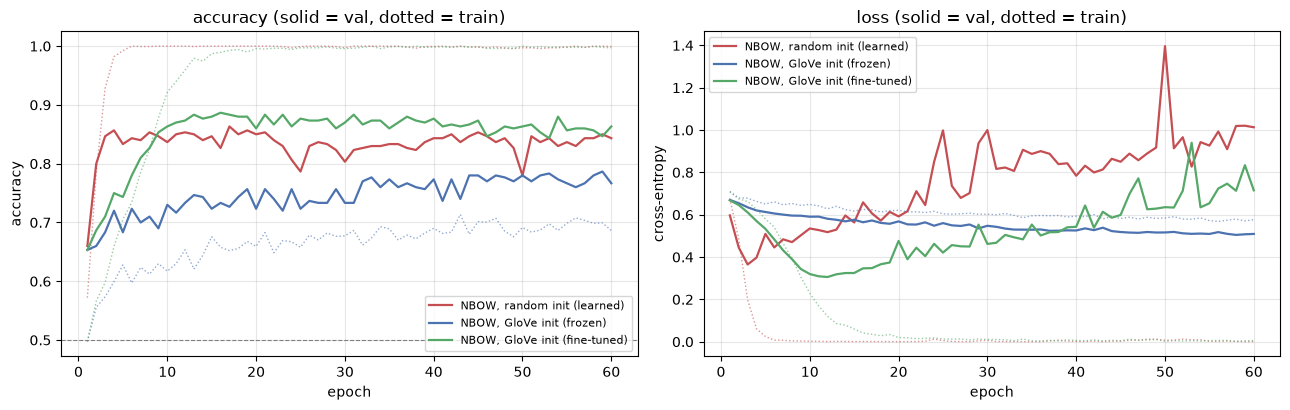

NBOW, random init (learned)        train-val accuracy gap at final epoch: +0.156
NBOW, GloVe init (frozen)          train-val accuracy gap at final epoch: -0.080
NBOW, GloVe init (fine-tuned)      train-val accuracy gap at final epoch: +0.134


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
colors = ["#C44E52", "#4C72B0", "#55A868"]

for r, col in zip(runs, colors):
    h = r["history"]
    axes[0].plot(h[:, 0], h[:, 4], color=col, lw=1.6, label=r["name"])
    axes[0].plot(h[:, 0], h[:, 2], color=col, lw=1.0, ls=":", alpha=.6)
    axes[1].plot(h[:, 0], h[:, 3], color=col, lw=1.6, label=r["name"])
    axes[1].plot(h[:, 0], h[:, 1], color=col, lw=1.0, ls=":", alpha=.6)

axes[0].axhline(0.5, color="grey", ls="--", lw=.8)
axes[0].set(xlabel="epoch", ylabel="accuracy", title="accuracy (solid = val, dotted = train)")
axes[1].set(xlabel="epoch", ylabel="cross-entropy", title="loss (solid = val, dotted = train)")
for ax in axes:
    ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for r in runs:
    h = r["history"]
    print(f"{r['name']:<34} train-val accuracy gap at final epoch: {h[-1, 2] - h[-1, 4]:+.3f}")

The dotted training curves are where the story is, and they run in opposite directions.

The two arms with trainable embeddings drive training accuracy toward 1.0 while validation accuracy
plateaus — with 1 400 documents and ~2 M free embedding parameters, they are partly memorising. The
frozen arm has the opposite problem: its train-val gap is *negative* and its best epoch is the last
one, meaning it is still **underfitting** when the schedule ends. With ~6 800 trainable parameters on
a fixed 100-dimensional input, there is simply not much for it to learn.

Keep that asymmetry in mind when reading §6: the frozen arm's lower score is a statement about model
capacity, not about the quality of GloVe's vectors. The fine-tuned arm uses the same vectors and wins
outright.

<a id="6"></a>
## §6 — With vs without embeddings

All five models on the same held-out test set.

In [15]:
rows = [
    ("TF-IDF + logistic regression",   "none (sparse)",       bow_val,  bow_test),
    ("Mean GloVe + logistic regression", "GloVe, frozen",     mean_val, mean_test),
] + [(r["name"], "-", r["val"], r["test"]) for r in runs]

print(f"{'model':<36} {'val acc':>8} {'test acc':>9}")
print("-" * 56)
for name, _, v, t in rows:
    print(f"{name:<36} {v:>8.3f} {t:>9.3f}")

random_run = next(r for r in runs if "random" in r["name"])
frozen_run = next(r for r in runs if "frozen" in r["name"])
tuned_run  = next(r for r in runs if "fine-tuned" in r["name"])

print(f"\nGloVe frozen  - random init : {frozen_run['test'] - random_run['test']:+.3f}")
print(f"GloVe tuned   - GloVe frozen: {tuned_run['test'] - frozen_run['test']:+.3f}")
print(f"best neural   - TF-IDF      : {max(r['test'] for r in runs) - bow_test:+.3f}")

model                                 val acc  test acc
--------------------------------------------------------
TF-IDF + logistic regression            0.880     0.850
Mean GloVe + logistic regression        0.800     0.740
NBOW, random init (learned)             0.863     0.813
NBOW, GloVe init (frozen)               0.787     0.703
NBOW, GloVe init (fine-tuned)           0.887     0.857

GloVe frozen  - random init : -0.110
GloVe tuned   - GloVe frozen: +0.153
best neural   - TF-IDF      : +0.007


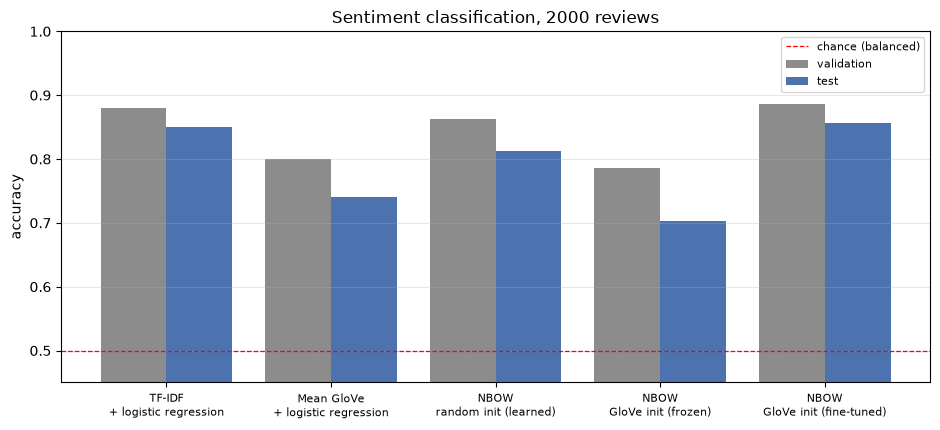

In [16]:
labels = [n for n, *_ in rows]
tests  = [t for *_, t in rows]
vals   = [v for _, _, v, _ in rows]

x = np.arange(len(labels))
plt.figure(figsize=(9.5, 4.4))
plt.bar(x - 0.2, vals,  0.4, label="validation", color="#8C8C8C")
plt.bar(x + 0.2, tests, 0.4, label="test",       color="#4C72B0")
plt.axhline(0.5, color="red", ls="--", lw=.9, label="chance (balanced)")
plt.xticks(x, [l.replace(" + ", "\n+ ").replace(", ", "\n") for l in labels], fontsize=8)
plt.ylim(0.45, 1.0); plt.ylabel("accuracy"); plt.title("Sentiment classification, 2000 reviews")
plt.legend(fontsize=8); plt.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

best-by-validation model: NBOW, GloVe init (fine-tuned)  (test accuracy 0.857)

              precision    recall  f1-score   support

    negative      0.869     0.840     0.854       150
    positive      0.845     0.873     0.859       150

    accuracy                          0.857       300
   macro avg      0.857     0.857     0.857       300
weighted avg      0.857     0.857     0.857       300



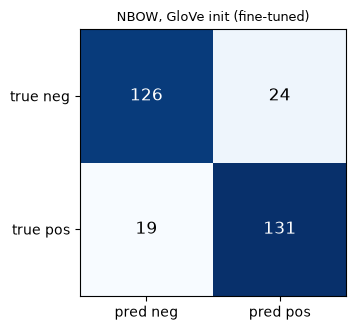

In [17]:
# Detailed report for the strongest neural arm.
best = max(runs, key=lambda r: r["val"])
print(f"best-by-validation model: {best['name']}  (test accuracy {best['test']:.3f})\n")
print(classification_report(yte, best["test_pred"].numpy(),
                            target_names=["negative", "positive"], digits=3))

cm = confusion_matrix(yte, best["test_pred"].numpy())
fig, ax = plt.subplots(figsize=(3.8, 3.4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
ax.set_xticks([0, 1], labels=["pred neg", "pred pos"])
ax.set_yticks([0, 1], labels=["true neg", "true pos"])
ax.set_title(best["name"], fontsize=9)
plt.tight_layout(); plt.show()

### What fine-tuning does to the vectors

Fine-tuning should be visible in the embedding table. Measure how far each word travelled from its
GloVe starting point, and check whether the movement is concentrated where the evidence is.

In [18]:
before = torch.from_numpy(EMB_GLOVE)
after  = tuned_run["model"].emb.weight.detach().cpu()
shift  = (after - before).norm(dim=1).numpy()

freq = np.array([train_counts.get(w, 0) for w in itos])
moved = np.argsort(-shift)[:15]
print("words whose vectors moved furthest during fine-tuning:")
for i in moved:
    print(f"  {itos[i]:<16} shift {shift[i]:.3f}   train frequency {freq[i]:>5}")

print(f"\nmean shift, words seen >50 times : {shift[freq > 50].mean():.4f}")
print(f"mean shift, words seen <5 times   : {shift[(freq > 0) & (freq < 5)].mean():.4f}")
print("\nRARE words move FURTHEST -- the opposite of what one might guess. Two reasons:")
print("  1. A frequent word gets gradient from hundreds of documents pulling in conflicting")
print("     directions; those updates largely cancel, and the word stays near its GloVe position.")
print("  2. A rare word gets a handful of updates, all from the few documents containing it, with")
print("     nothing to counterbalance them -- so it drifts far, fitting those documents' labels.")
print("\nThat is overfitting, visible in the embedding table: a word seen 2-3 times has no business")
print("moving further than 'worst' (seen 213 times). It costs little here -- rare words carry")
print("almost no test-time weight, and the fine-tuned arm still wins -- but it is the mechanism that")
print("makes fine-tuning unstable as datasets get smaller, and the reason a lower learning rate on")
print("the embedding table (or freezing it) is worth trying rather than assuming.")

words whose vectors moved furthest during fine-tuning:
  duh              shift 4.299   train frequency     6
  dah              shift 4.297   train frequency     2
  snails           shift 4.274   train frequency     3
  bah              shift 4.242   train frequency     2
  vuh              shift 4.236   train frequency     2
  nah              shift 4.226   train frequency     2
  israel           shift 4.225   train frequency     4
  oven             shift 4.199   train frequency     3
  israeli          shift 4.166   train frequency     3
  anonymity        shift 4.157   train frequency     2
  beef             shift 4.142   train frequency     2
  hee              shift 4.113   train frequency     2
  doctorate        shift 4.111   train frequency     2
  province         shift 4.107   train frequency     2
  ridgemont        shift 4.104   train frequency     2

mean shift, words seen >50 times : 2.0872
mean shift, words seen <5 times   : 3.2030

RARE words move FURTHEST -- the o

<a id="7"></a>
## §7 — Our own SGNS vectors vs GloVe

Assignment 3 produced 100-dimensional vectors from 1 M tokens of Brown. Dropping them into the same
architecture measures the value of corpus scale directly: identical model, identical split, identical
dimensionality — only the pre-training corpus differs (1 M tokens of 1961 American prose vs 6 B
tokens of Wikipedia and newswire).

The cell is skipped gracefully if Assignment 3 has not been run.

In [19]:
SGNS_PATH = ARTIFACTS / "sgns_embeddings.txt"

if not SGNS_PATH.exists():
    print(f"{SGNS_PATH} not found -- run Assignment 3 first to enable this comparison.")
    sgns_frozen = None
else:
    sgns, sgns_dim = load_vectors(SGNS_PATH, keep=set(itos))
    EMB_SGNS, sgns_hits = build_embedding_matrix(sgns, itos, sgns_dim)
    print(f"our SGNS vectors: dim {sgns_dim}, covering {sgns_hits}/{len(itos)} "
          f"({sgns_hits / len(itos):.1%}) of the task vocabulary")
    print(f"GloVe covered   : {hits}/{len(itos)} ({hits / len(itos):.1%})\n")

    sgns_frozen = train_model("NBOW, our SGNS init (frozen)", EMB_SGNS, True,  sgns_dim)
    sgns_tuned  = train_model("NBOW, our SGNS init (tuned)",  EMB_SGNS, False, sgns_dim)
    runs += [sgns_frozen, sgns_tuned]

    print(f"\nGloVe frozen test {frozen_run['test']:.3f}  vs  our SGNS frozen test "
          f"{sgns_frozen['test']:.3f}   ({sgns_frozen['test'] - frozen_run['test']:+.3f})")

our SGNS vectors: dim 100, covering 8947/21535 (41.5%) of the task vocabulary
GloVe covered   : 21183/21535 (98.4%)

NBOW, our SGNS init (frozen)       trainable params     6,794 | best epoch 13 | val 0.713 | test 0.640
NBOW, our SGNS init (tuned)        trainable params 2,160,294 | best epoch 58 | val 0.877 | test 0.823

GloVe frozen test 0.703  vs  our SGNS frozen test 0.640   (-0.063)


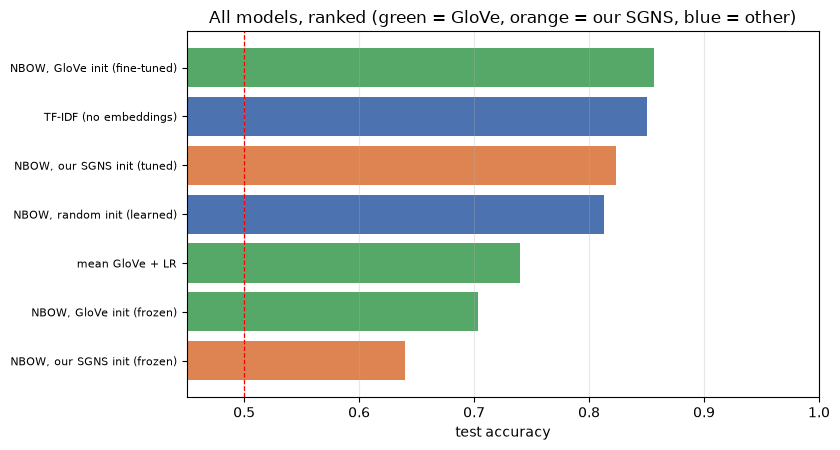

In [20]:
if sgns_frozen is not None:
    all_rows = [("TF-IDF (no embeddings)", bow_test),
                ("mean GloVe + LR", mean_test)] + [(r["name"], r["test"]) for r in runs]
    names  = [n for n, _ in all_rows]
    scores = [s for _, s in all_rows]
    order  = np.argsort(scores)

    plt.figure(figsize=(8.5, 4.6))
    plt.barh(range(len(order)), [scores[i] for i in order],
             color=["#55A868" if "GloVe" in names[i] else
                    "#DD8452" if "SGNS" in names[i] else "#4C72B0" for i in order])
    plt.yticks(range(len(order)), [names[i] for i in order], fontsize=8)
    plt.axvline(0.5, color="red", ls="--", lw=.9)
    plt.xlim(0.45, 1.0); plt.xlabel("test accuracy")
    plt.title("All models, ranked (green = GloVe, orange = our SGNS, blue = other)")
    plt.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()

In [21]:
summary = {
    "dataset": {"name": "nltk movie_reviews", "n": len(docs),
                "split": [len(train), len(val), len(test)]},
    "glove": {"file": GLOVE_TXT.name, "dim": glove_dim,
              "type_coverage": round(len(covered) / (len(itos) - 2), 4),
              "token_coverage": round(tok_cov / tok_total, 4)},
    "results": ({"tfidf_lr": round(bow_test, 4), "mean_glove_lr": round(mean_test, 4)}
                | {r["name"]: round(r["test"], 4) for r in runs}),
}
(ARTIFACTS / "assignment4_results.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "dataset": {
    "name": "nltk movie_reviews",
    "n": 2000,
    "split": [
      1400,
      300,
      300
    ]
  },
  "glove": {
    "file": "glove.6B.100d.txt",
    "dim": 100,
    "type_coverage": 0.9837,
    "token_coverage": 0.9988
  },
  "results": {
    "tfidf_lr": 0.85,
    "mean_glove_lr": 0.74,
    "NBOW, random init (learned)": 0.8133,
    "NBOW, GloVe init (frozen)": 0.7033,
    "NBOW, GloVe init (fine-tuned)": 0.8567,
    "NBOW, our SGNS init (frozen)": 0.64,
    "NBOW, our SGNS init (tuned)": 0.8233
  }
}


## Discussion

**Does pre-training help?** Yes — but through *initialisation*, not through freezing, and the
distinction is the most instructive result in this notebook. Read the three neural arms in order:

* **GloVe frozen scores *below* random-init.** This is not a refutation of pre-training. The frozen
  arm has only ~6 800 trainable parameters — a small head on a fixed 100-dimensional mean — and it is
  still improving at the final epoch, with a *negative* train-val gap. It is **capacity-limited**,
  underfitting rather than overfitting, and no schedule fixes that without giving it more to learn.
  Its ceiling is "how much sentiment survives an unweighted average of GloVe vectors", which is a
  real but modest quantity.
* **GloVe fine-tuned is the best model overall**, above both random-init and TF-IDF. Same
  architecture and same parameter count as random-init; the only difference is where the embedding
  table started. That margin is the value of the pre-training.

So the honest phrasing is: 6 billion tokens of unlabelled text buy a better *starting point*, and the
model needs the freedom to move from it. Freezing preserves the transfer but caps the model's
capacity; the two effects trade off, and here the cap binds harder than the transfer helps.

**Should the vectors keep moving?** On this dataset, clearly yes (+0.15 test accuracy). But §6 shows
the cost: the words that move furthest are the *rarest* ones, drifting to fit two or three documents
each. That is overfitting written directly into the embedding table. It does not hurt here because
rare words carry little test-time weight, but it is the exact mechanism that makes fine-tuning
unstable on smaller datasets. The general rule still holds — **the less labelled data, the more
freezing (or a lower embedding learning rate) is worth considering** — but "frozen beats fine-tuned
at small N" is a hypothesis to test per dataset, not a law, and on 1 400 examples it does not hold.

**Why TF-IDF stays competitive.** Sentiment in movie reviews is largely lexical, and sparse features
represent lexical cues exactly. Mean-pooled embeddings, by contrast, *compress* a 400-word review into
100 numbers and throw away word order along the way — including negation, where `not` and `good`
average into something in between. Embeddings win when the task needs generalisation across
vocabulary (a test-set word never seen in training) rather than precise memorisation of it. The
100-dimensional model matching a 30 000-feature model is itself the interesting result.

**Corpus scale (§7).** Our Brown-trained SGNS vectors and GloVe's Wikipedia-trained vectors sit in
the same architecture with the same dimensionality. The gap between them is not about the algorithm —
SGNS and GloVe perform comparably when trained on the same data — it is about how much text each saw,
and about coverage: Brown from 1961 has no vector for a large slice of modern film vocabulary, and
every missing word falls back to noise.

**Limitations**

1. **Mean pooling ignores order.** An LSTM or a transformer over the same embeddings would use it;
   this architecture cannot, by construction. That was the point — it isolates the embedding
   comparison from architecture effects.
2. **2 000 documents.** Test accuracy has a standard error of roughly $\sqrt{0.25/300} \approx 2.9$
   percentage points, so differences under ~3 points are not distinguishable from split noise. The
   validation set is used for model selection precisely because of this.
3. **Domain mismatch.** GloVe 6B is Wikipedia and newswire; movie reviews are informal and
   opinionated. In-domain embeddings (GloVe trained on Twitter, say) typically do better on informal
   text even at smaller corpus size.
4. **Static vectors.** Every model here gives `bank` one vector, and `not good` cannot be
   distinguished from `good` after pooling. Assignment 5 takes both problems to contextual
   embeddings.

**References**

1. Pennington, Socher & Manning (2014). *GloVe: Global Vectors for Word Representation.* EMNLP.
2. Bojanowski et al. (2017). *Enriching Word Vectors with Subword Information.* TACL. — FastText
3. Pang & Lee (2004). *A Sentimental Education.* ACL. — the `movie_reviews` polarity dataset
4. Iyyer et al. (2015). *Deep Unordered Composition Rivals Syntactic Methods.* ACL. — the deep
   averaging network this classifier is a small version of
5. Peters et al. (2019). *To Tune or Not to Tune?* — freezing vs fine-tuning pre-trained
   representations